In [57]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

import torch
import model_utils
import Plotter
from Frame import Frame
import pickle 
import numpy as np
import Utils
import Plotters

path_to_mesh = 'D:/Documents/model_gaussian_splatting/model/mesh'    
image_path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov30_2024_11_12_darkan/'
dict_path = 'D:/Documents/data_for_gs/fly_gray/dict/frames_model.pkl'

with open(dict_path, 'rb') as file:
    data_dict = pickle.load(file)



root,body,right_wing,left_wing,list_joints_pitch_update = model_utils.initilize_skeleton_and_skin(path_to_mesh,skeleton_scale=1/1000)
joint_list,skin,weights,bones = model_utils.build_skeleton(root,body,right_wing,left_wing)


frame = 1447
frames_per_cam = [Frame(image_path,frame,cam_num,frames_dict = data_dict) for cam_num in range(4)]
camera_pixel = np.vstack([frame.camera_center_to_pixel_ray(([frame.cm[0],frame.cm[1]])) for frame in  frames_per_cam])
camera_center = np.vstack([frame.X0.T for frame in  frames_per_cam])
cm_point = Utils.triangulate_least_square(camera_center,camera_pixel)
ew_to_lab = list(data_dict[frame][1].values())[0]['ew_to_lab']
cm_point_lab = torch.tensor(ew_to_lab @ cm_point,device='cuda').float()



In [50]:
cm_point_lab


tensor([[0.0128, 0.0083, 0.0006],
        [0.0128, 0.0083, 0.0006],
        [0.0128, 0.0083, 0.0006],
        ...,
        [0.0140, 0.0070, 0.0002],
        [0.0140, 0.0070, 0.0002],
        [0.0140, 0.0070, 0.0002]], device='cuda:0')

C:\Users\Roni\AppData\Local\Temp\ipykernel_29432\2429101062.py:9: UserWarning:

To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).



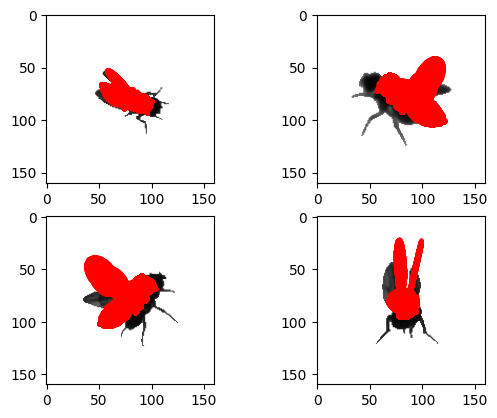

In [107]:
body_angles = torch.tensor([-96,  -19,  5],device='cuda')
right_wing_angles = torch.tensor([-70,-80,-50],device='cuda')
left_wing_angles = torch.tensor([90,-60,50],device='cuda')


means3D = model_utils.transform_pose(skin,weights,body_angles,
                            list_joints_pitch_update,joint_list,bones,cm_point_lab,
                            right_wing_angles,left_wing_angles)
means3D_ew = torch.tensor(torch.tensor(ew_to_lab.T).cuda().float() @ means3D.T,device='cuda').float().T

Plotters.plot_projections(means3D_ew.cpu(),frames_per_cam)


In [104]:
import Plotter
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default='browser'

fig = go.Figure()
Plotter.plot_skeleton(bones,fig,{},{}, name = ['neck_head','neck_thorax','thorax_abdomen','right_wing','left_wing'])
Plotter.plot_skin(fig,means3D.cpu(),'skin',skip_skin_points = 10,color = 'red',size = 3)
# Plotter.plot_skin(fig,left_wing.ptcloud_skin.cpu(),'skin',skip_skin_points = 10,color = 'blue',size = 3)
# Plotter.plot_skin(fig,body.ptcloud_skin.cpu(),'skin',skip_skin_points = 10,color = 'green',size = 3)
fig.show()



d:\Documents\model_gaussian_splatting\Plotters.py:69: UserWarning:

No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored



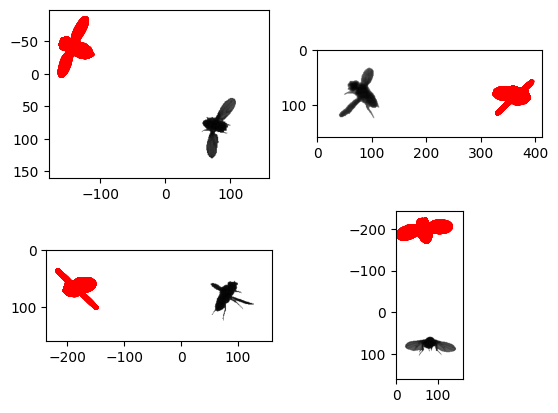

In [3]:

import numpy as np
body_angles = torch.tensor([20,-45,30],device='cuda')
body_location = torch.tensor([1,2,0],device='cuda')/1000
right_wing_angles = torch.tensor([60,45,5],device='cuda')
left_wing_angles = torch.tensor([-60,45,-5],device='cuda')
weights = weights.cuda()

means3D = Utils.transform_pose(skin,weights,body_angles,
                            list_joints_pitch_update,joint_list,bones,body_location,
                            right_wing_angles,left_wing_angles)

fig = go.Figure()
Plotter.plot_skeleton(bones,fig,{},{}, name = ['neck_head','neck_thorax','thorax_abdomen','right_wing','left_wing'])
Plotter.plot_skin(fig,means3D.cpu(),'skin',skip_skin_points = 10,color = 'red',size = 3)
fig.show()